# <b>Machine Learning Model Jupyter Notebook</B>

Supervised learning machine learning model that takes in:
    <li> Chromosome
    <li> Chromosome Start Position
    <li> Chromosome End Position
    <li> Mutated From Allele
    <li> Mutated To Allele

Make sure to run pip install -r requirements.txt

```
python -m venv venv 
source venv/bin/activate   # On Windows: venv\Scripts\activate
pip install pandas numpy scikit-learn scipy
pip freeze > requirements.txt

python -m ipykernel install --user --name=venv --display-name "Python (venv)"
```


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
mutation_original = pd.read_csv('Mutation_original.csv')

In [3]:
mutation_original_df = mutation_original[['icgc_specimen_id', 'chromosome', 'chromosome_start', 'chromosome_end',
                                            'mutation_type', 'mutated_from_allele', 'mutated_to_allele', 'Cancer type']].copy()

# Add lengths (since larger mutations could be a sign of cancer type?)
mutation_original_df['mutation_length'] = abs(mutation_original_df['chromosome_end'] - mutation_original_df['chromosome_start'] + 1)

# Encode categorical columns
for col in ['chromosome', 'mutation_type', 'mutated_from_allele', 'mutated_to_allele']:
    mutation_original_df[col] = LabelEncoder().fit_transform(mutation_original_df[col])

# Normalise chromosome lengths based on the size of the chromosome it is in
chrom_lengths = {
    '1': 248956422, '2': 242193529, '3': 198295559, '4': 190214555,
    '5': 181538259, '6': 170805979, '7': 159345973, '8': 145138636,
    '9': 138394717, '10': 133797422, '11': 135086622, '12': 133275309,
    '13': 114364328, '14': 107043718, '15': 101991189, '16': 90338345,
    '17': 83257441, '18': 80373285, '19': 58617616, '20': 64444167,
    '21': 46709983, '22': 50818468, 'X': 156040895, 'Y': 57227415
}

mutation_original_df['chromosome_norm_start'] = mutation_original_df.apply(
    lambda x: x['chromosome_start'] / chrom_lengths.get(str(x['chromosome']), 1), axis=1
)
mutation_original_df['chromosome_norm_end'] = mutation_original_df.apply(
    lambda x: x['chromosome_end'] / chrom_lengths.get(str(x['chromosome']), 1), axis=1
)

In [60]:
# X = mutation_original_df.drop(columns=['icgc_specimen_id', 'Cancer type'])
X = mutation_original_df[['chromosome_start', 'chromosome_end', 'mutated_from_allele', 'mutated_to_allele']]
y = mutation_original_df['Cancer type']

# Encode cancer type labels (target variable)
y = LabelEncoder().fit_transform(y)

# Scale features for distance-based models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(mutation_original)

In [ ]:
# knn = KNeighborsClassifier(n_neighbors=5)

# # Train model
# knn.fit(X_train, y_train)

# # Predict on test data
# y_pred = knn.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

# nbrs = NearestNeighbors(n_neighbors=5, metric='euclidean')
# nbrs.fit(X_scaled)

# # Example: find 5 nearest samples to the first mutation entry
# distances, indices = nbrs.kneighbors([X_scaled[0]])
# print("Nearest samples indices:", indices)
# print("Distances:", distances)

Accuracy: 0.3025938025938026

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.28      0.24      7292
           1       0.34      0.40      0.37     11826
           2       0.31      0.35      0.33     13073
           3       0.29      0.25      0.27     10556
           4       0.27      0.18      0.22      7154
           5       0.37      0.29      0.32     10705

    accuracy                           0.30     60606
   macro avg       0.30      0.29      0.29     60606
weighted avg       0.31      0.30      0.30     60606

Nearest samples indices: [[     0      1 180425 295416 127291]]
Distances: [[0.         0.         0.00134823 0.00266565 0.0026671 ]]


In [61]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4744744744744745

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.39      0.38      7292
           1       0.52      0.52      0.52     11826
           2       0.48      0.47      0.48     13073
           3       0.47      0.46      0.46     10556
           4       0.39      0.42      0.41      7154
           5       0.55      0.54      0.55     10705

    accuracy                           0.47     60606
   macro avg       0.46      0.47      0.47     60606
weighted avg       0.48      0.47      0.48     60606



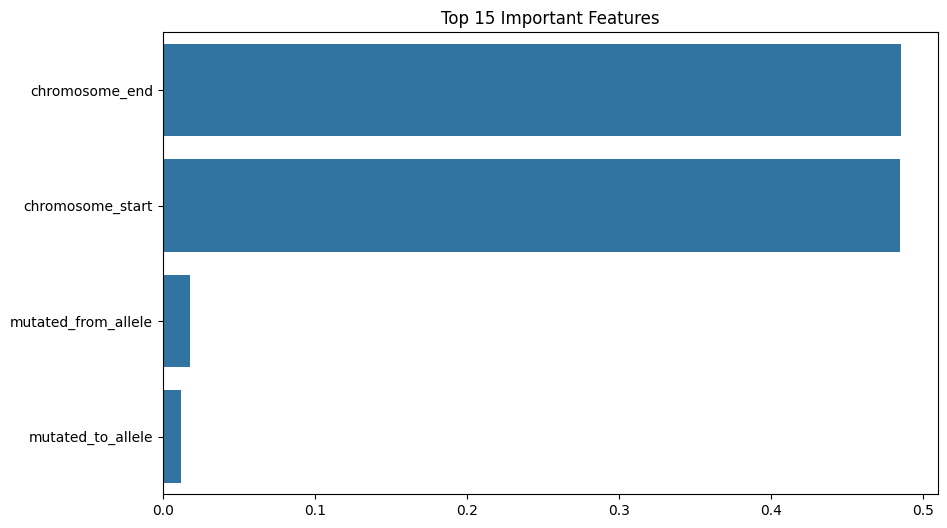

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:15], y=np.array(features)[indices])
plt.title("Top 15 Important Features")
plt.show()

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Assuming you already have X_train, X_test, y_train, y_test

# Define search space for hyperparameters
param_space = {
    'n_estimators': Integer(100, 600),
    'max_depth': Integer(5, 50),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5),
    'max_features': Categorical(['sqrt', 'log2']),
    'bootstrap': Categorical([True, False])
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

opt = BayesSearchCV(
    estimator=rf,
    search_spaces=param_space,
    n_iter=30,  # Number of optimization iterations (increase for better results)
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Run optimization
opt.fit(X_train, y_train)

Fitting 10 folds for each of 1 candidates, totalling 10 fits


In [ ]:
print("Best Parameters Found:", opt.best_params_)
print("Best CV Accuracy:", opt.best_score_)

# Predict on test data
y_pred = opt.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.4023859023859024

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.31      0.30      7258
           1       0.46      0.45      0.46     11881
           2       0.41      0.39      0.40     13216
           3       0.40      0.39      0.40     10551
           4       0.32      0.34      0.33      7137
           5       0.47      0.48      0.47     10563

    accuracy                           0.40     60606
   macro avg       0.39      0.39      0.39     60606
weighted avg       0.40      0.40      0.40     60606



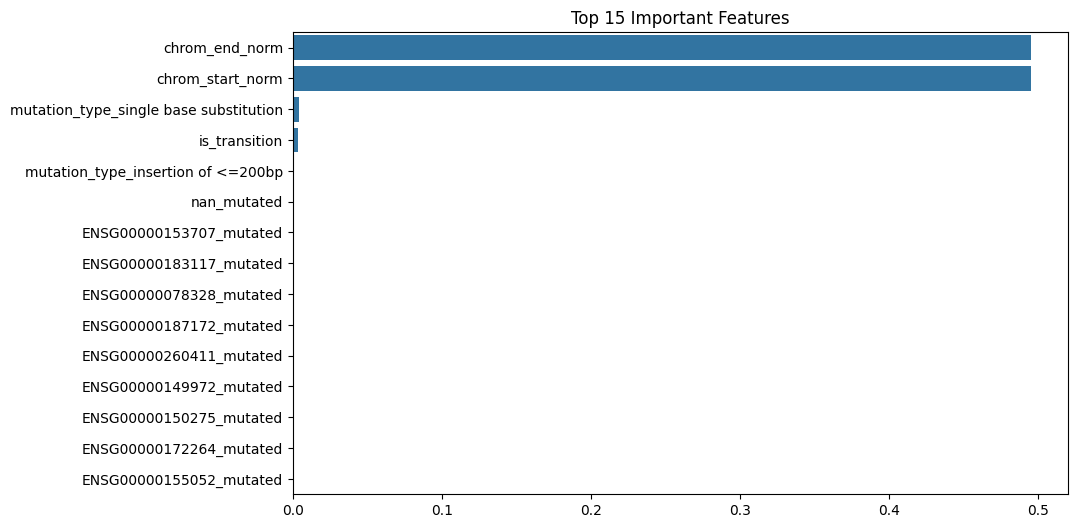

In [ ]:
# Test gpt
df = mutation_original.copy()
df = df.dropna(subset=['icgc_specimen_id', 'chromosome', 'chromosome_start', 'chromosome_end', 'mutation_type', 'Cancer type'])

# Ensure strings
df['mutation_type'] = df['mutation_type'].astype(str)
df['mutated_from_allele'] = df['mutated_from_allele'].astype(str)
df['mutated_to_allele'] = df['mutated_to_allele'].astype(str)
df['gene_affected'] = df['gene_affected'].astype(str)

# -----------------------------
# 2️⃣ Feature Engineering
# -----------------------------

# (a) Top gene mutation binary features
top_genes = df['gene_affected'].value_counts().head(30).index
for gene in top_genes:
    df[f'{gene}_mutated'] = (df['gene_affected'] == gene).astype(int)

# (b) One-hot encode mutation type
df = pd.get_dummies(df, columns=['mutation_type'], drop_first=True)

# (c) Transition vs transversion
df['is_transition'] = (
    ((df['mutated_from_allele'] == 'A') & (df['mutated_to_allele'] == 'G')) |
    ((df['mutated_from_allele'] == 'G') & (df['mutated_to_allele'] == 'A')) |
    ((df['mutated_from_allele'] == 'C') & (df['mutated_to_allele'] == 'T')) |
    ((df['mutated_from_allele'] == 'T') & (df['mutated_to_allele'] == 'C'))
).astype(int)


# -----------------------------
# 3️⃣ Prepare Features and Labels
# -----------------------------
X = df.drop(columns=['icgc_specimen_id', 'Cancer type', 'gene_affected', 'mutated_from_allele', 'mutated_to_allele', 'chromosome', 'chromosome_start', 'chromosome_end', 'consequence_type'])
y = LabelEncoder().fit_transform(df['Cancer type'])

# -----------------------------
# 4️⃣ Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features if needed
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 5️⃣ Train Random Forest
# -----------------------------
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)

# -----------------------------
# 6️⃣ Evaluate
# -----------------------------
y_pred = rf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 7️⃣ Optional: Feature Importance
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:15], y=np.array(features)[indices][:15])
plt.title("Top 15 Important Features")
plt.show()

In [18]:
print(mutation_original)

       icgc_specimen_id chromosome  chromosome_start  chromosome_end  \
0              SP112909          1          17558891        17558891   
1              SP112909          1          17558891        17558891   
2              SP112909          1          46934561        46934561   
3              SP112909          1          63782783        63782783   
4              SP112909          1          63782783        63782783   
...                 ...        ...               ...             ...   
303023         SP196149          X         151668225       151668225   
303024         SP196149          X         151734873       151734873   
303025         SP196149          X         151764009       151764009   
303026         SP196149          X         155223366       155223366   
303027         SP196149          X         155223366       155223366   

                   mutation_type mutated_from_allele mutated_to_allele  \
0       single base substitution                   C         

✅ Accuracy: 0.4097

Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.32      0.32      4444
           1       0.47      0.47      0.47      7815
           2       0.40      0.41      0.41      8193
           3       0.40      0.38      0.39      6577
           4       0.33      0.34      0.34      4387
           5       0.47      0.47      0.47      6557

    accuracy                           0.41     37973
   macro avg       0.40      0.40      0.40     37973
weighted avg       0.41      0.41      0.41     37973



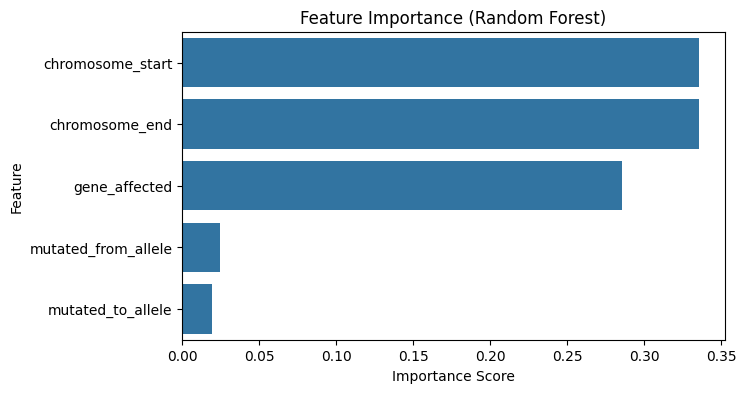

In [20]:
# Post sams feedback
df = mutation_original[['chromosome_start', 'chromosome_end', 'mutation_type', 'mutated_from_allele', 'mutated_to_allele', 'gene_affected', 'Cancer type']].dropna()

# -----------------------------
# 2️⃣ Encode categorical columns
# -----------------------------
le_from = LabelEncoder()
le_to = LabelEncoder()
le_ct = LabelEncoder()
le_gene = LabelEncoder()
le_label = LabelEncoder()

df['mutated_from_allele'] = le_from.fit_transform(df['mutated_from_allele'].astype(str))
df['mutated_to_allele'] = le_to.fit_transform(df['mutated_to_allele'].astype(str))
df['mutation_type'] = le_ct.fit_transform(df['mutation_type'].astype(str))
df['gene_affected'] = le_gene.fit_transform(df['gene_affected'].astype(str))
df['Cancer type'] = le_label.fit_transform(df['Cancer type'].astype(str))

# -----------------------------
# 3️⃣ Prepare features and labels
# -----------------------------
X = df[['chromosome_start', 'chromosome_end', 'mutated_from_allele', 'mutated_to_allele', 'gene_affected']]
y = df['Cancer type']

# -----------------------------
# 4️⃣ Split dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize numeric columns (optional, helps tree splits if scales differ)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 5️⃣ Train Random Forest
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# -----------------------------
# 6️⃣ Evaluate model
# -----------------------------
y_pred = rf.predict(X_test_scaled)

print("✅ Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 7️⃣ Feature importance plot
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Accuracy: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits


KeyboardInterrupt: 